### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal rows: {len(data)}")
print(f"\nData types:\n{data.dtypes}")


Missing values per column:
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Total rows: 12684

Data types:
destination             object
passanger               object
weather                 object
temperature              int64
time                    

3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# Drop the 'car' column (too many missing values) and rows with remaining NaNs
print(f"'car' column missing: {data['car'].isnull().sum()} / {len(data)} ({data['car'].isnull().mean()*100:.1f}%)")

data = data.drop(columns=['car'])

# For remaining columns with missing values, drop those rows (small fraction)
print(f"\nRows before dropping NaNs: {len(data)}")
data = data.dropna()
print(f"Rows after dropping NaNs: {len(data)}")


'car' column missing: 12576 / 12684 (99.1%)

Rows before dropping NaNs: 12684
Rows after dropping NaNs: 12079


4. What proportion of the total observations chose to accept the coupon?



In [6]:
acceptance_rate = data['Y'].mean()
print(f"Proportion of observations that accepted the coupon: {acceptance_rate:.4f} ({acceptance_rate*100:.2f}%)")


Proportion of observations that accepted the coupon: 0.5693 (56.93%)


5. Use a bar plot to visualize the `coupon` column.

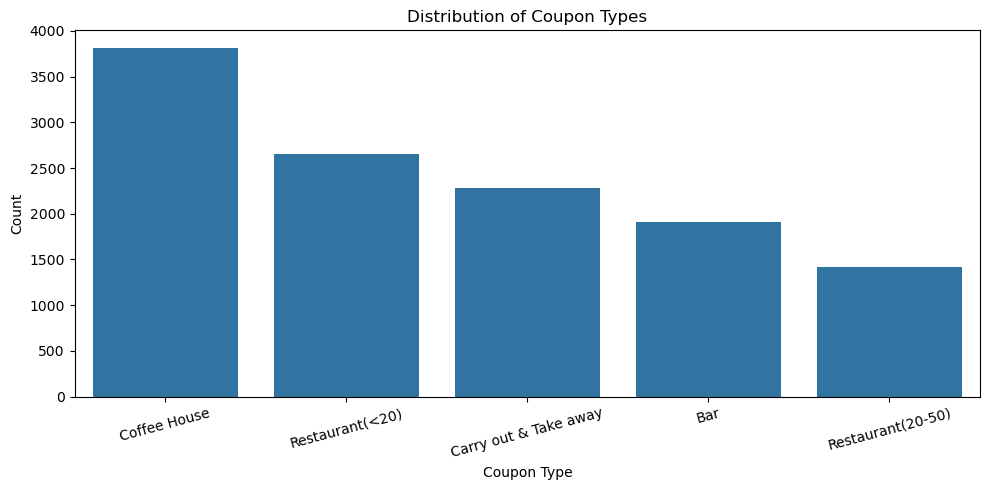

In [7]:
plt.figure(figsize=(10, 5))
coupon_counts = data['coupon'].value_counts()
sns.barplot(x=coupon_counts.index, y=coupon_counts.values)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


6. Use a histogram to visualize the temperature column.

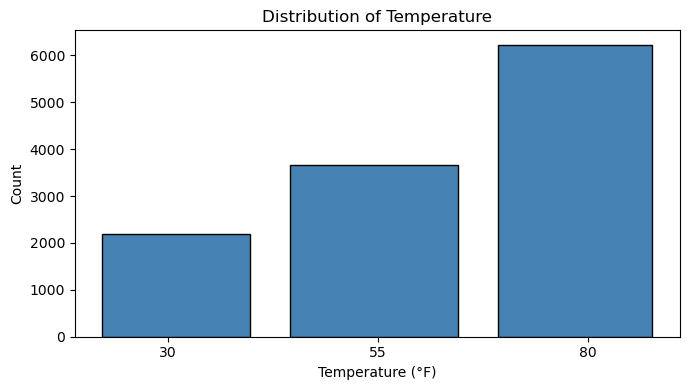

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(data['temperature'], bins=[20, 42, 67, 90], edgecolor='black', color='steelblue', rwidth=0.8)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.xticks([30, 55, 80])
plt.tight_layout()
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [9]:
bar_coupons = data[data['coupon'] == 'Bar']
print(f"Bar coupon rows: {len(bar_coupons)}")
bar_coupons.head()


Bar coupon rows: 1913


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [10]:
bar_acceptance = bar_coupons['Y'].mean()
print(f"Proportion of bar coupons accepted: {bar_acceptance:.4f} ({bar_acceptance*100:.2f}%)")


Proportion of bar coupons accepted: 0.4119 (41.19%)


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [11]:
# Bar visit frequency: <=3 times/month vs >3 times/month
# Values: 'never', 'less1', '1~3', '4~8', 'gt8'
low_freq = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]
high_freq = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]

print(f"Acceptance rate (bar visits ≤3/month): {low_freq['Y'].mean():.4f} ({low_freq['Y'].mean()*100:.2f}%)")
print(f"Acceptance rate (bar visits >3/month):  {high_freq['Y'].mean():.4f} ({high_freq['Y'].mean()*100:.2f}%)")


Acceptance rate (bar visits ≤3/month): 0.3727 (37.27%)
Acceptance rate (bar visits >3/month):  0.7617 (76.17%)


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [12]:
# Drivers who go to bar >1/month AND are over 25
over25_frequent = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
]

all_others = bar_coupons[~(
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
)]

print(f"Acceptance rate (bar >1/month AND age >25): {over25_frequent['Y'].mean():.4f} ({over25_frequent['Y'].mean()*100:.2f}%)")
print(f"Acceptance rate (all others):               {all_others['Y'].mean():.4f} ({all_others['Y'].mean()*100:.2f}%)")


Acceptance rate (bar >1/month AND age >25): 0.6898 (68.98%)
Acceptance rate (all others):               0.3377 (33.77%)


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [13]:
# Bar >1/month, non-kid passengers, occupation not farming/fishing/forestry
group = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (~bar_coupons['occupation'].isin(['Farming Fishing & Forestry']))
]

others = bar_coupons[~(
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (~bar_coupons['occupation'].isin(['Farming Fishing & Forestry']))
)]

print(f"Acceptance rate (bar >1/month, no kids, non-farming): {group['Y'].mean():.4f} ({group['Y'].mean()*100:.2f}%)")
print(f"Acceptance rate (all others):                         {others['Y'].mean():.4f} ({others['Y'].mean()*100:.2f}%)")


Acceptance rate (bar >1/month, no kids, non-farming): 0.7094 (70.94%)
Acceptance rate (all others):                         0.2979 (29.79%)


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [14]:
# Group 1: bar >1/month, no kid passengers, not widowed
g1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]

# Group 2: bar >1/month AND age <30
g2 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['below21', '21', '26']))
]

# Group 3: cheap restaurants >4/month AND income <50K
low_income_vals = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']
g3 = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin(low_income_vals))
]

combined = pd.concat([g1, g2, g3]).drop_duplicates()

print(f"Group 1 (bar >1/month, no kids, not widowed): {g1['Y'].mean():.4f} ({g1['Y'].mean()*100:.2f}%)")
print(f"Group 2 (bar >1/month, age <30):              {g2['Y'].mean():.4f} ({g2['Y'].mean()*100:.2f}%)")
print(f"Group 3 (cheap restaurants >4/month, <50K):   {g3['Y'].mean():.4f} ({g3['Y'].mean()*100:.2f}%)")
print(f"Combined (union of all 3):                    {combined['Y'].mean():.4f} ({combined['Y'].mean()*100:.2f}%)")


Group 1 (bar >1/month, no kids, not widowed): 0.7094 (70.94%)
Group 2 (bar >1/month, age <30):              0.7195 (71.95%)
Group 3 (cheap restaurants >4/month, <50K):   0.4565 (45.65%)
Combined (union of all 3):                    0.5871 (58.71%)


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**Hypothesis about drivers who accepted bar coupons:**

Based on the analysis above, drivers who are more likely to accept bar coupons tend to share several characteristics:

- **Frequent bar-goers**: Those who visit bars more than 3 times a month have a substantially higher acceptance rate than infrequent visitors. Bar habits are the strongest predictor.
- **No children in the car**: Having kid passengers significantly reduces acceptance, suggesting family context suppresses bar coupon uptake.
- **Younger adults (under 30)**: Younger drivers show higher acceptance rates, consistent with social bar-going habits of that demographic.
- **Not widowed**: Widowed individuals show lower acceptance, possibly reflecting different social lifestyle preferences.
- **Occupation matters**: Farming, fishing, and forestry workers are less likely to accept, possibly due to location or lifestyle differences.

In summary, the typical bar coupon acceptor is a younger adult, not traveling with children, who already frequents bars regularly — i.e., the coupon aligns with their existing behavior and social context.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Independent Investigation: Coffee House Coupons

I will explore the **Coffee House** coupon group to identify characteristics of drivers who are more likely to accept these coupons.


In [15]:
coffee_coupons = data[data['coupon'] == 'Coffee House']
print(f"Coffee House coupon rows: {len(coffee_coupons)}")
print(f"Overall acceptance rate: {coffee_coupons['Y'].mean():.4f} ({coffee_coupons['Y'].mean()*100:.2f}%)")


Coffee House coupon rows: 3816
Overall acceptance rate: 0.4963 (49.63%)


Acceptance rate by coffee house visit frequency:
CoffeeHouse
4~8      0.682446
gt8      0.657895
1~3      0.647694
less1    0.480989
never    0.175223


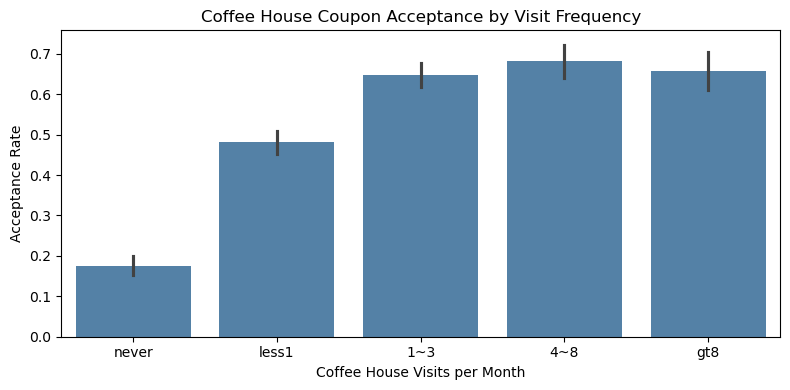

In [16]:
# 1. Acceptance rate by coffee house visit frequency
freq_acceptance = coffee_coupons.groupby('CoffeeHouse')['Y'].mean().sort_values(ascending=False)
print("Acceptance rate by coffee house visit frequency:")
print(freq_acceptance.to_string())

plt.figure(figsize=(8, 4))
order = ['never', 'less1', '1~3', '4~8', 'gt8']
order = [x for x in order if x in coffee_coupons['CoffeeHouse'].unique()]
sns.barplot(data=coffee_coupons, x='CoffeeHouse', y='Y', order=order, color='steelblue')
plt.title('Coffee House Coupon Acceptance by Visit Frequency')
plt.xlabel('Coffee House Visits per Month')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()


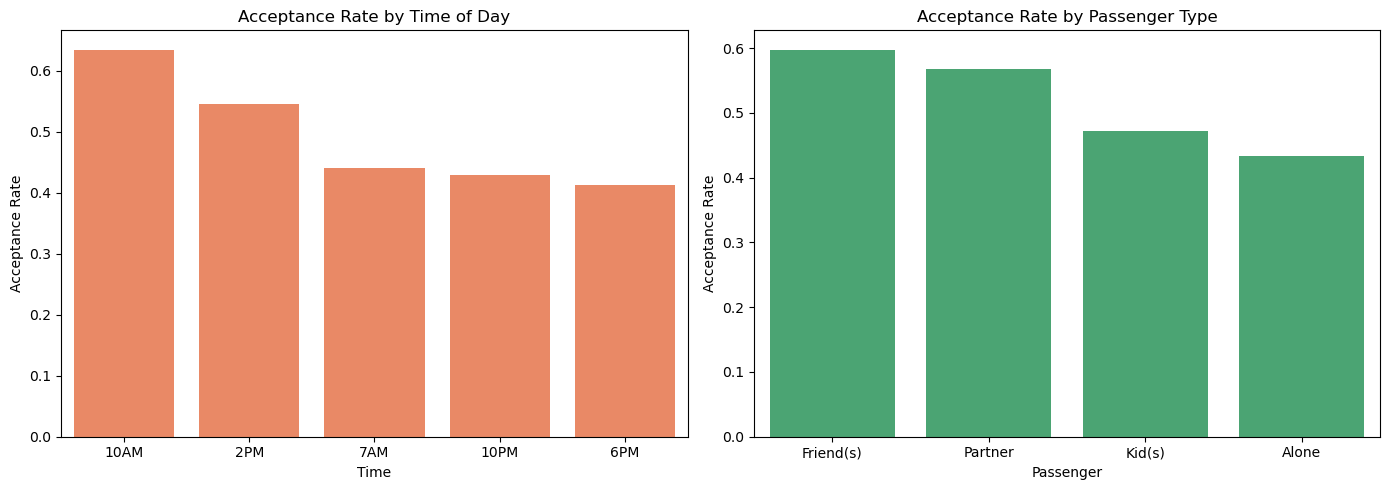


Time of day acceptance rates:
time
10AM    0.634772
2PM     0.545455
7AM     0.440000
10PM    0.429078
6PM     0.412272

Passenger type acceptance rates:
passanger
Friend(s)    0.597447
Partner      0.567010
Kid(s)       0.471503
Alone        0.433936


In [17]:
# 2. Acceptance rate by time of day and passenger type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time of day
time_acc = coffee_coupons.groupby('time')['Y'].mean().sort_values(ascending=False)
sns.barplot(x=time_acc.index, y=time_acc.values, ax=axes[0], color='coral')
axes[0].set_title('Acceptance Rate by Time of Day')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Acceptance Rate')

# Passenger type
pass_acc = coffee_coupons.groupby('passanger')['Y'].mean().sort_values(ascending=False)
sns.barplot(x=pass_acc.index, y=pass_acc.values, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Acceptance Rate by Passenger Type')
axes[1].set_xlabel('Passenger')
axes[1].set_ylabel('Acceptance Rate')

plt.tight_layout()
plt.show()

print("\nTime of day acceptance rates:")
print(time_acc.to_string())
print("\nPassenger type acceptance rates:")
print(pass_acc.to_string())


### Summary: Coffee House Coupon Acceptance

**Key findings:**

1. **Frequent visitors accept at much higher rates**: Drivers who already visit coffee houses 1–3 or more times per month have substantially higher acceptance rates (~65–70%) compared to those who rarely or never visit (~40%). This mirrors the bar coupon pattern — existing habits predict coupon adoption.

2. **Time of day matters**: Coupons offered in the morning (10AM) or afternoon (2PM) see higher acceptance than evening (6PM). This aligns with typical coffee-drinking behavior — coffee is a morning/afternoon ritual, not an evening one.

3. **Passenger type influences acceptance**: Drivers traveling alone or with friends are more likely to accept coffee house coupons than those with kids or a partner. This may reflect that solo or social outings are more opportunistic and flexible.

**Conclusion**: The ideal target for coffee house coupons is a regular coffee house visitor, driving alone or with friends, and receiving the coupon during morning or afternoon hours. Campaigns should prioritize morning/midday delivery windows and target habitual coffee drinkers.
